**CELL 1 — Import Library**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

**Penerangan mudah:**

Library ini digunakan untuk:
*   torch — bina dan latih model AI.
*   torchvision — muat turun dataset CIFAR-10.
*   matplotlib — paparkan gambar.
*   numpy — urus data nombor.

**CELL 2 — Load Dataset CIFAR-10**

In [ ]:
# Tetapkan transformasi untuk tukar imej kepada Tensor dan normalisasi data
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

# Muat turun training dataset
trainset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# Muat turun testing dataset
testset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# Nama kelas dalam CIFAR-10
classes = (
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
)

print("Bilangan training images:", len(trainset))
print("Bilangan testing images:", len(testset))

Bilangan training images: 50000
Bilangan testing images: 10000


**CELL 3 — Tengok Gambar Dataset**

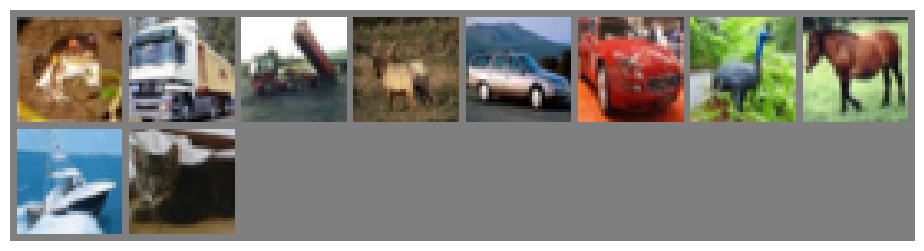

Label gambar:
['frog', 'truck', 'truck', 'deer', 'automobile', 'automobile', 'bird', 'horse', 'ship', 'cat']


In [ ]:
# Fungsi untuk paparkan imej
def imshow(img):
    img = img / 2 + 0.5  # Tukar semula nilai imej selepas normalisasi
    npimg = img.numpy()
    plt.figure(figsize=(12, 3))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    plt.show()

# Ambil 10 gambar pertama daripada training dataset
images = []
labels = []

for i in range(10):
    image, label = trainset[i]
    images.append(image)
    labels.append(label)

# Gabungkan gambar menjadi grid
imshow(torchvision.utils.make_grid(images))

print("Label gambar:")
print([classes[label] for label in labels])

**CELL 4 — DataLoader / Batch**

In [ ]:
batch_size = 64

trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=batch_size,
    shuffle=True
)

testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=batch_size,
    shuffle=False
)

print("Batch size yang digunakan:", batch_size)

Batch size yang digunakan: 64


**CELL 5 — Bina CNN**

In [ ]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        # Convolution layer pertama:
        # Input = 3 channel RGB, Output = 32 feature maps
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)

        # Convolution layer kedua
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        # Max pooling untuk kecilkan saiz imej
        self.pool = nn.MaxPool2d(2, 2)

        # Fully connected layers
        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, 10)

        # Activation function
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))  # 32x32 -> 16x16
        x = self.pool(self.relu(self.conv2(x)))  # 16x16 -> 8x8

        x = x.view(-1, 64 * 8 * 8)  # Flatten data
        x = self.relu(self.fc1(x))
        x = self.fc2(x)

        return x

# Guna GPU jika ada, jika tiada guna CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNN().to(device)

print(model)
print("Device yang digunakan:", device)

CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=4096, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (relu): ReLU()
)
Device yang digunakan: cpu


**CELL 6 — Loss Function dan Optimizer**

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Loss function: CrossEntropyLoss")
print("Optimizer: Adam")
print("Learning rate: 0.001")

Loss function: CrossEntropyLoss
Optimizer: Adam
Learning rate: 0.001


**CELL 7 — Train CNN**

In [ ]:
epochs = 10

for epoch in range(epochs):
    running_loss = 0.0
    correct = 0
    total = 0

    model.train()

    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)

        # Kosongkan gradient lama
        optimizer.zero_grad()

        # Prediction daripada model
        outputs = model(images)

        # Kira loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Kemaskini parameter model
        optimizer.step()

        running_loss += loss.item()

        # Kira training accuracy
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_accuracy = 100 * correct / total

    print(f"Epoch [{epoch+1}/{epochs}], "
          f"Loss: {running_loss/len(trainloader):.4f}, "
          f"Training Accuracy: {train_accuracy:.2f}%")

Epoch [1/10], Loss: 1.3573, Training Accuracy: 51.31%
Epoch [2/10], Loss: 0.9703, Training Accuracy: 65.78%
Epoch [3/10], Loss: 0.8138, Training Accuracy: 71.71%
Epoch [4/10], Loss: 0.6955, Training Accuracy: 75.70%
Epoch [5/10], Loss: 0.5968, Training Accuracy: 79.14%
Epoch [6/10], Loss: 0.5090, Training Accuracy: 82.09%
Epoch [7/10], Loss: 0.4241, Training Accuracy: 85.20%
Epoch [8/10], Loss: 0.3526, Training Accuracy: 87.57%
Epoch [9/10], Loss: 0.2814, Training Accuracy: 90.28%
Epoch [10/10], Loss: 0.2221, Training Accuracy: 92.30%


**CELL 8 — Test CNN**

In [ ]:
correct = 0
total = 0

model.eval()

with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total

print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 70.88%


CELL 9 — Prediction 10 Gambar

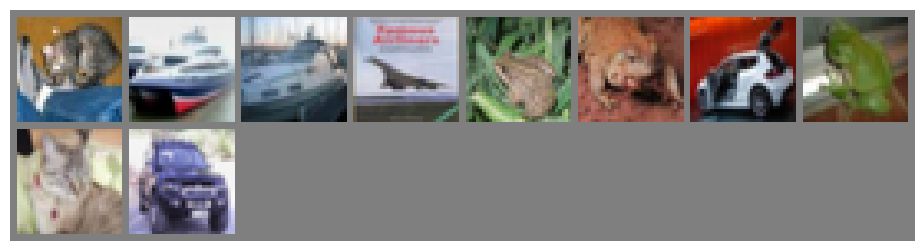

Label sebenar:
['cat', 'ship', 'ship', 'airplane', 'frog', 'frog', 'automobile', 'frog', 'cat', 'automobile']
Prediction model:
['dog', 'ship', 'ship', 'ship', 'frog', 'frog', 'automobile', 'frog', 'cat', 'automobile']

Bilangan prediction betul daripada 10 gambar: 8/10


In [ ]:
# Ambil satu batch daripada test dataset
images, labels = next(iter(testloader))

# Pindahkan gambar ke device
images = images.to(device)

# Model buat prediction
model.eval()

with torch.no_grad():
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

# Paparkan 10 gambar pertama
imshow(torchvision.utils.make_grid(images[:10].cpu()))

print("Label sebenar:")
print([classes[labels[i]] for i in range(10)])

print("Prediction model:")
print([classes[predicted[i].cpu().item()] for i in range(10)])

# Kira prediction yang betul daripada 10 gambar
correct_10 = (predicted[:10].cpu() == labels[:10]).sum().item()

print(f"\nBilangan prediction betul daripada 10 gambar: {correct_10}/10")